In [1]:
%matplotlib widget

import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
import pytesseract
from android_bot import image_utils
from matplotlib.patches import Polygon
from android_bot import get_cards_tablet

In [2]:
# Load image into a NumPy array

# img_path = "frames_tablet/dealer_4_cards.png"  # player has d
# split2 / split5 finger position
img_path = "frames_tablet/7dQd_Jh.png"

img_np = image_utils.load_rdb(img_path)

print(f"Loaded {img_path}")
print(f"shape: {img_np.shape}, dtype: {img_np.dtype}")

Loaded frames_tablet/7dQd_Jh.png
shape: (1440, 2304, 3), dtype: uint8


In [3]:
cards_poly = get_cards_tablet.middle_cards_poly

poly = Polygon(
    cards_poly, closed=True, fill=False, ec="black", lw=2
)

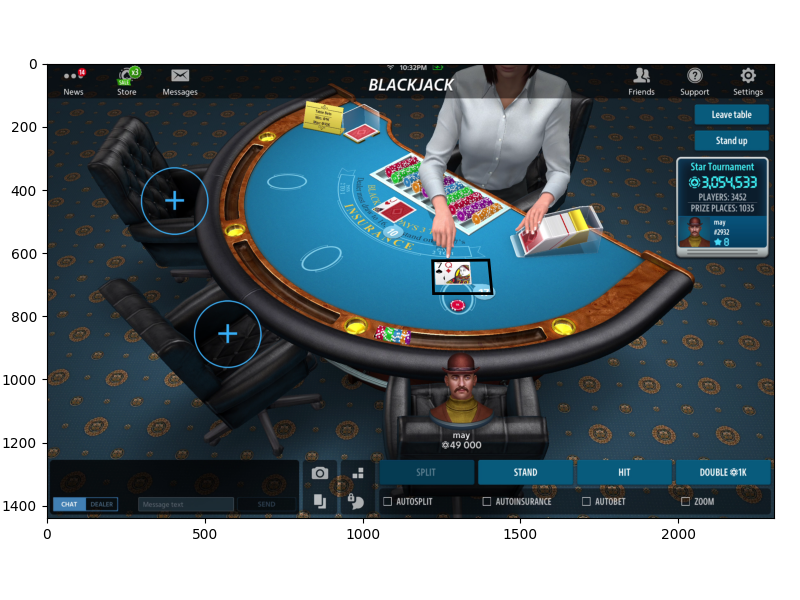

In [4]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
f.tight_layout()
ax.set_aspect(1)
ax.imshow(img_np, aspect='equal')
ax.add_patch(poly)

In [5]:
import get_cards_tablet
import ocr_cards

In [6]:
get_cards_tablet.is_split_pair(img_np)

np.False_

In [7]:
left_cards = get_cards_tablet.get_player_cards_left_img(img_np)
right_cards = get_cards_tablet.get_player_cards_right_img(img_np)
mid_cards = get_cards_tablet.get_player_cards_middle_img(img_np)

Text(0.5, 1.0, '[]')

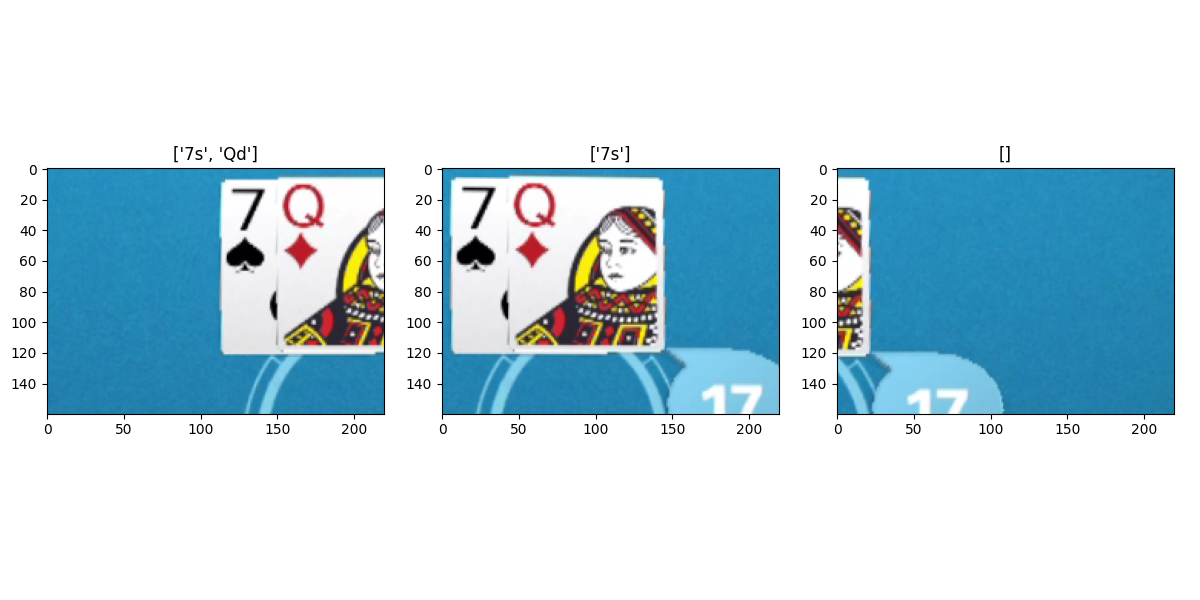

In [8]:
f, [ax0, ax1, ax2] = plt.subplots(1, 3, figsize=(12, 6))
f.tight_layout()

left_title = get_cards_tablet.get_cards(left_cards)
mid_title = get_cards_tablet.get_cards(mid_cards)
right_title = get_cards_tablet.get_cards(right_cards)

ax0.imshow(left_cards, aspect='equal')
ax1.imshow(mid_cards, aspect='equal')
ax2.imshow(right_cards, aspect='equal')
ax0.set_title(left_title)
ax1.set_title(mid_title)
ax2.set_title(right_title)

In [9]:
matches, n_matches = \
    image_utils.find_subimages(
        mid_cards,
        get_cards_tablet._suit_templates,
        threshold=0.9,
        keys=get_cards_tablet._suits
    )

digit_images = get_cards_tablet.extract_card_values_img(mid_cards, matches)

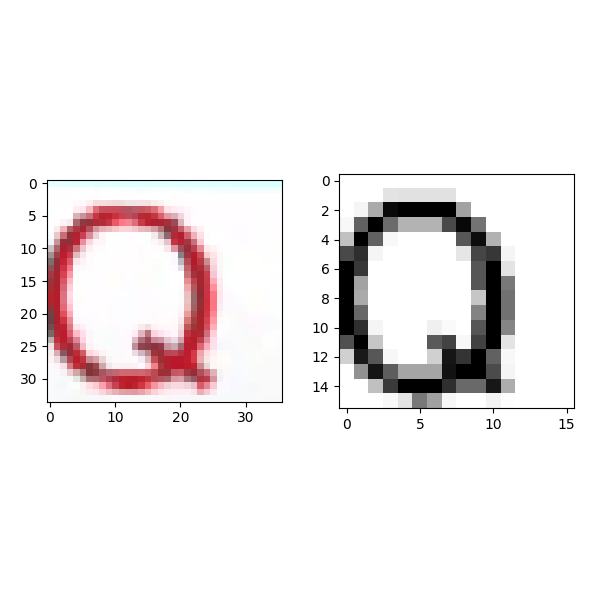

In [16]:
f, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 6))
f.tight_layout()

digit = digit_images["d"][0]
digit_bnw = ocr_cards.to_bnw(digit)
character_bnw_small = cv2.resize(digit_bnw, (16, 16), interpolation=cv2.INTER_AREA)

ax1.imshow(digit, aspect='equal')
ax2.imshow(character_bnw_small, aspect='equal', cmap='gray')

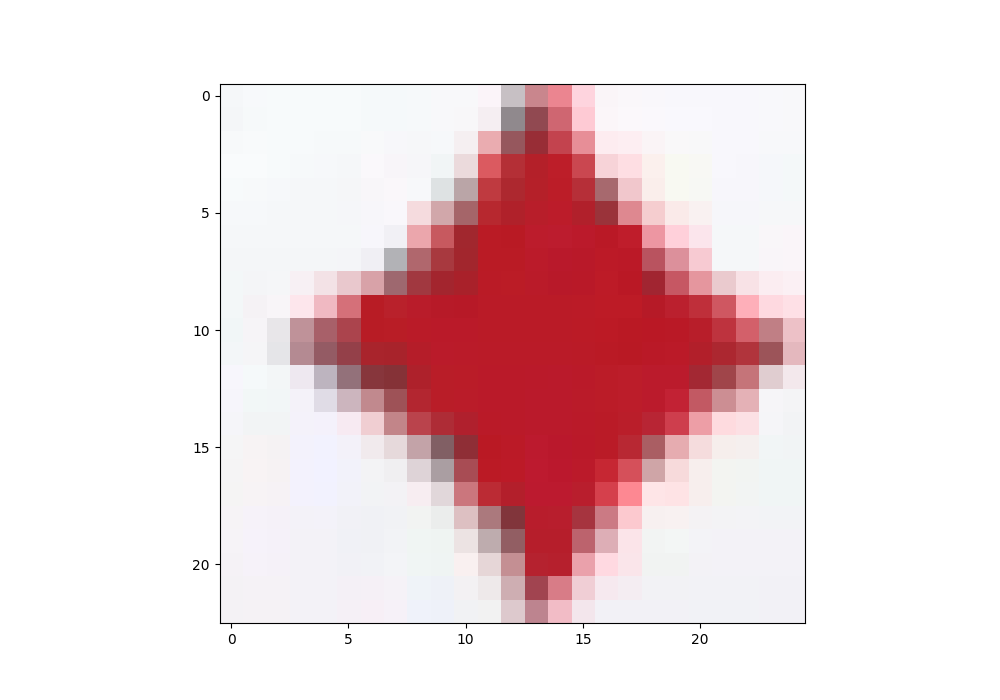

In [21]:
# d_img = mid_cards[42:65, 45:70]
d_img = mid_cards[42:65, 45:70]
f, ax0 = plt.subplots(1, 1, figsize=(10, 7))
ax0.imshow(d_img, cmap="gray")

In [ ]:
# image_utils.save_rgb_png(d_img, "suits_tablet/d.png")

In [13]:
import pytesseract
pytesseract_config = "--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789JQKA"


text = pytesseract.image_to_string(digit_bnw, config=pytesseract_config).strip()
    

In [14]:
print(text)

Q


In [15]:
_six_16x16 = image_utils.load_rdb("digits/10_16x16.png")
_six_16x16 = cv2.cvtColor(_six_16x16, cv2.COLOR_RGB2GRAY)


match_six = cv2.matchTemplate(
    digit_bnw, _six_16x16, cv2.TM_CCOEFF_NORMED
)
print(match_six.max())

FileNotFoundError: [Errno 2] No such file or directory: 'digits/10_16x16.png'

In [1]:
from android_bot import get_cards_tablet
from android_bot import image_utils
from android_bot import ocr_cards

In [2]:
player_cards_map = {
    "2c6h4d_7s": ["2c", "6h", "4d"],
    "7sQd_Jh": ["7s", "Qd"],
    "9sTd_Qh": ["9s", "Td"],
    "Ts6d_3d": ["Ts", "6d"],
    "dealer_3_cards": ["4s", "Ts"],
    "dealer_4_cards_2": ["2h", "8c", "9c"],
    "dealer_4_cards": ["Qd", "7h"],
    "dealer_5_cards": ["3c", "Ac", "7c"],
    "pair_bust_3": [["7s", "5s"], ["5s", "Kh", "2d"]],
    "pair_bust_before_removal": [["2d", "Td"], ["8h", "Jh"]],
    "pair_bust": [["Jd", "Tc"], []],
    "player_4_cards": ["4h", "2s", "5c", "Qc"],
    "player_5_cards": ["2c", "7h"],
    "player_blackjack": ["Ac", "Jc"],
    "split_1": [["6c", "5c"], ["6s", "Ts", "3c"]],
    "split_2": [["6c", "5c", "7d", "Ah"], ["6s", "Ts", "3c", "2h"]],
    "split_3": [["6c", "5c", "7d", "Ah"], ["6s", "Ts", "3c", "2h"]],
    "split_5": [["2d", "Td"], ["2d", "8h"]],
    "Th4c_8d": ["Th", "4c"]
}

In [3]:
test_results = {}

for name, expected_result in player_cards_map.items():
    img_test = image_utils.load_rdb(f"../frames_tablet/{name}.png")

    is_split = get_cards_tablet.is_split_pair(img_test)

    cards_values = []
    if is_split:
        cards_left = get_cards_tablet.get_player_cards_left_img(img_test)
        cards_right = get_cards_tablet.get_player_cards_right_img(img_test)
        cards_values.append(get_cards_tablet.get_cards(cards_left))
        cards_values.append(get_cards_tablet.get_cards(cards_right))
    else:
        cards_mid = get_cards_tablet.get_player_cards_middle_img(img_test)
        cards_values.extend(get_cards_tablet.get_cards(cards_mid))

    test_results[name] = (cards_values == expected_result)
    if not test_results[name]:
        print(f"Test {name} failed: expected {expected_result}, got {cards_values}")
    else:
        print(f"Test {name} passed.")

Test 2c6h4d_7s passed.
Test 7sQd_Jh passed.
Test 9sTd_Qh passed.
Test Ts6d_3d passed.
Test dealer_3_cards passed.
Test dealer_4_cards_2 passed.
Test dealer_4_cards passed.
Test dealer_5_cards passed.
Test pair_bust_3 passed.
Test pair_bust_before_removal passed.
Test pair_bust passed.
Test player_4_cards passed.
Test player_5_cards passed.
Test player_blackjack passed.
Test split_1 passed.
Test split_2 passed.
Test split_3 passed.
Test split_5 passed.
Test Th4c_8d passed.


In [4]:
d = image_utils.load_rdb("suits_tablet/d.png")

FileNotFoundError: [Errno 2] No such file or directory: 'suits_tablet/d.png'

In [ ]:
f, [ax0, ax1] = plt.subplots(1, 2, figsize=(8, 6))
ax0.imshow(d, aspect='equal')
ax1.imshow(d[1:, :], aspect='equal')

NameError: name 'plt' is not defined

In [ ]:
# image_utils.save_rgb_png(d[1:, :], "suits_tablet/d.png")